<a href="https://colab.research.google.com/github/di5han/AIFinalAssessment/blob/main/NewReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# CELL 1: REGRESSION DEPENDENCIES & ENVIRONMENT SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing, Validation & Feature Selection Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

# Regression Estimators
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Continuous Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set clean aesthetic styling parameters for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Cell 1 complete: Regression workflow environment initialized!")

Cell 1 complete: Regression workflow environment initialized!


In [32]:
# CELL 2: DATA LOADING & INITIAL SHAPE PROFILING
# Load dataset directly from your specified Google Drive path
filepath_reg = "/content/drive/MyDrive/AIAssignment/Lifestyle and Wellbeing Data.csv"
df = pd.read_csv(filepath_reg)

print("=== RAW DATASET CHARACTERISTICS ===")
print(f"Shape Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("=== COMPLETE VARIABLE INVENTORY ===")
print(df.columns.tolist())

print("\n--- Initial Snapshot (First 3 Rows) ---")
display(df.head(3))

=== RAW DATASET CHARACTERISTICS ===
Shape Dimensions: 15972 rows, 24 columns

=== COMPLETE VARIABLE INVENTORY ===
['Timestamp', 'FRUITS_VEGGIES', 'DAILY_STRESS', 'PLACES_VISITED', 'CORE_CIRCLE', 'SUPPORTING_OTHERS', 'SOCIAL_NETWORK', 'ACHIEVEMENT', 'DONATION', 'BMI_RANGE', 'TODO_COMPLETED', 'FLOW', 'DAILY_STEPS', 'LIVE_VISION', 'SLEEP_HOURS', 'LOST_VACATION', 'DAILY_SHOUTING', 'SUFFICIENT_INCOME', 'PERSONAL_AWARDS', 'TIME_FOR_PASSION', 'WEEKLY_MEDITATION', 'AGE', 'GENDER', 'WORK_LIFE_BALANCE_SCORE']

--- Initial Snapshot (First 3 Rows) ---


,Timestamp,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,...,SLEEP_HOURS,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,AGE,GENDER,WORK_LIFE_BALANCE_SCORE
0,2007-07-15,3,2,2,5,0,5,2,0,1,...,7,5,5,1,4,0,5,36 to 50,Female,609.5
1,2007-07-15,2,3,4,3,8,10,5,2,2,...,8,2,2,2,3,2,6,36 to 50,Female,655.6
2,2007-07-15,2,3,3,4,4,10,3,2,2,...,8,10,2,2,4,8,3,36 to 50,Female,631.6


In [33]:
# CELL 3: FEATURE EXTRACTION & DATA PURGING / CLEANING
# Isolate your chosen 5 features and target variable
features = ["SLEEP_HOURS", "DAILY_STRESS", "DAILY_STEPS", "BMI_RANGE", "TIME_FOR_PASSION"]
target = "WORK_LIFE_BALANCE_SCORE"

# Slice and create a deep copy to prevent SettingWithCopy warnings
data = df[features + [target]].copy()

# Enforce strict numerical validation across columns (coercing invalid strings to NaN)
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop missing rows to ensure clean downstream mathematical execution
data = data.dropna()

print("=== CLEANED REGRESSION MATRIX DATA INFO ===")
data.info()

print(f"\nRemaining structural null values: {data.isnull().sum().sum()}")
print("\n=== DESCRIPTIVE STATISTICAL DISTRIBUTION SUMMARY ===")
display(data.describe())

=== CLEANED REGRESSION MATRIX DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 15971 entries, 0 to 15971
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SLEEP_HOURS              15971 non-null  int64  
 1   DAILY_STRESS             15971 non-null  float64
 2   DAILY_STEPS              15971 non-null  int64  
 3   BMI_RANGE                15971 non-null  int64  
 4   TIME_FOR_PASSION         15971 non-null  int64  
 5   WORK_LIFE_BALANCE_SCORE  15971 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 873.4 KB

Remaining structural null values: 0

=== DESCRIPTIVE STATISTICAL DISTRIBUTION SUMMARY ===


,SLEEP_HOURS,DAILY_STRESS,DAILY_STEPS,BMI_RANGE,TIME_FOR_PASSION,WORK_LIFE_BALANCE_SCORE
count,15971.000000,15971.000000,15971.000000,15971.000000,15971.000000,15971.000000
mean,7.042953,2.791685,5.703588,1.410619,3.326279,666.750510
std,1.199053,1.367801,2.891102,0.491962,2.729128,45.021103
min,1.000000,0.000000,1.000000,1.000000,0.000000,480.000000
25%,6.000000,2.000000,3.000000,1.000000,1.000000,636.000000
50%,7.000000,3.000000,5.000000,1.000000,3.000000,667.700000
75%,8.000000,4.000000,8.000000,2.000000,5.000000,698.500000
max,10.000000,5.000000,10.000000,2.000000,10.000000,820.200000


Generating feature distribution graphs...


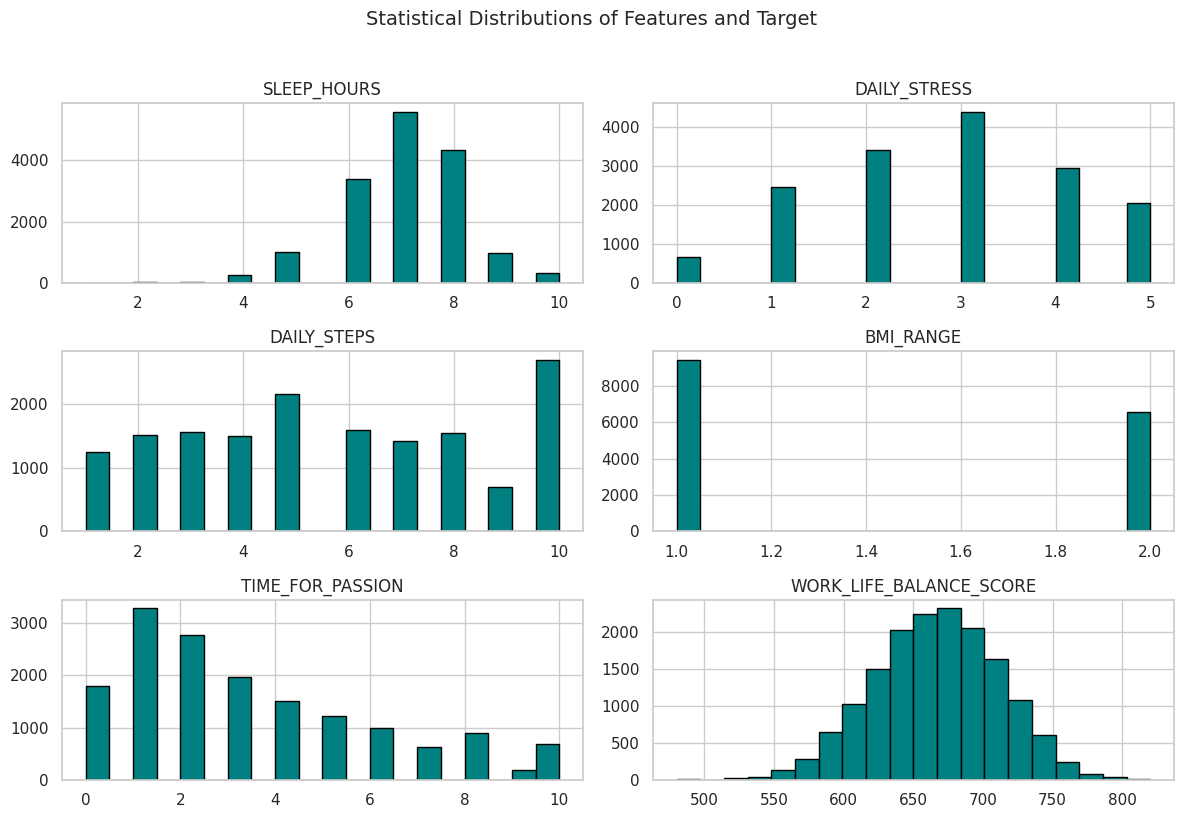

Generating correlation matrix heatmap...


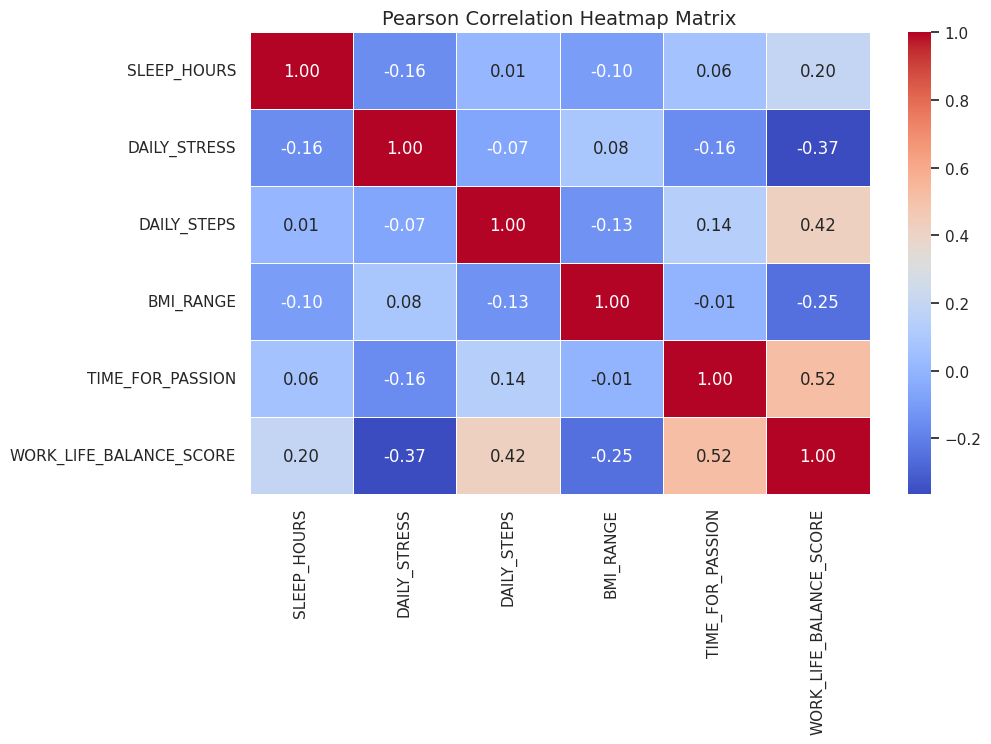

Generating target relationship scatter plots...


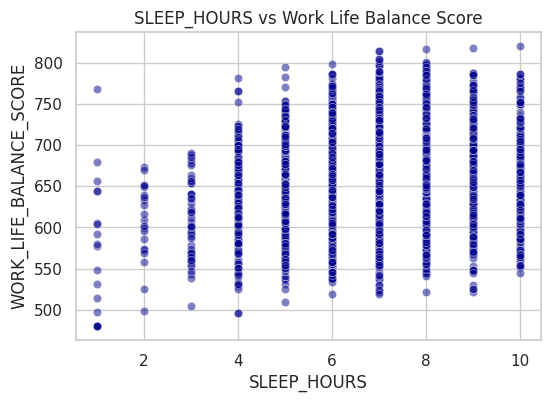

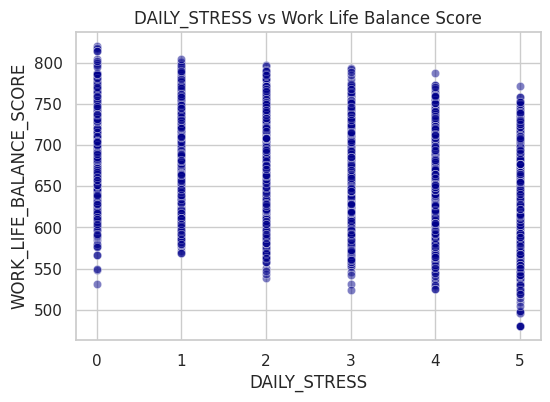

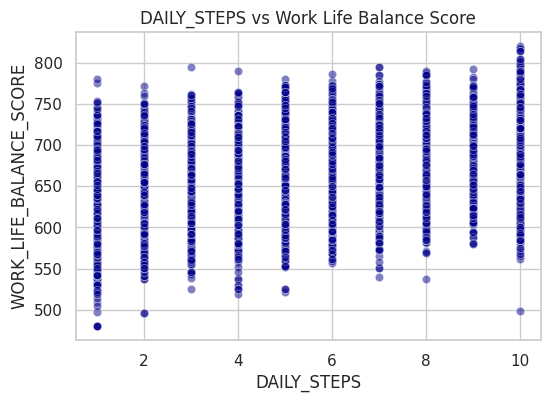

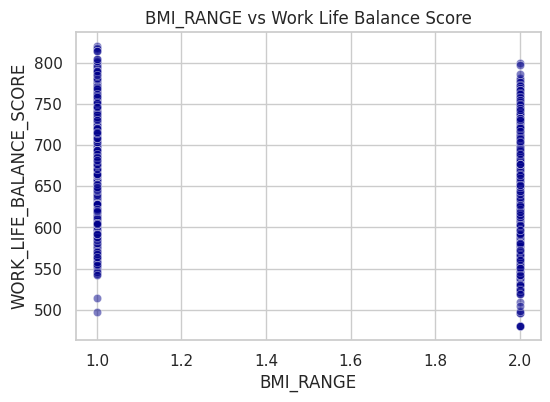

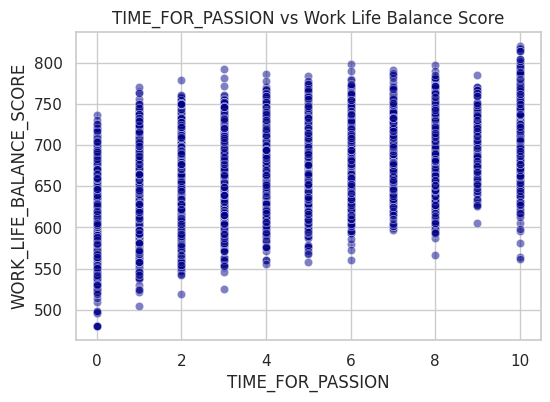

Generating diagnostic outlier boxplots...


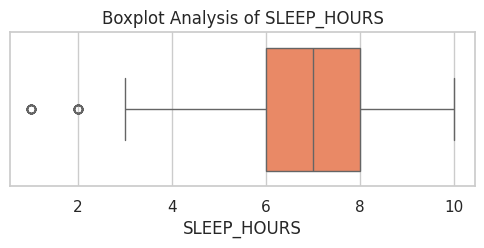

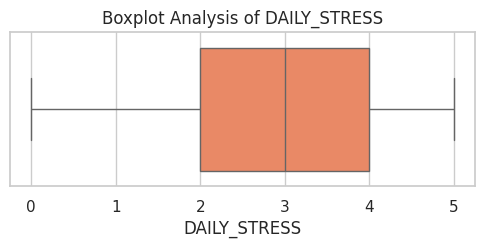

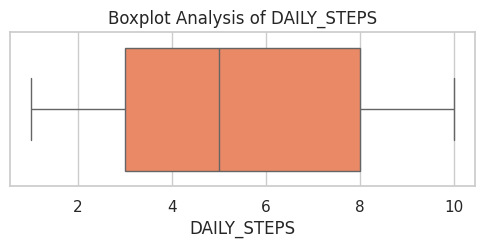

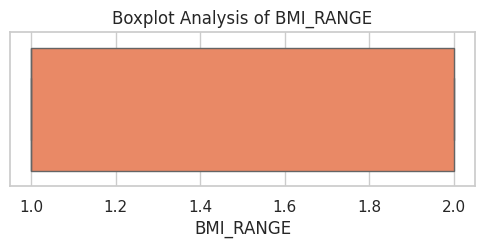

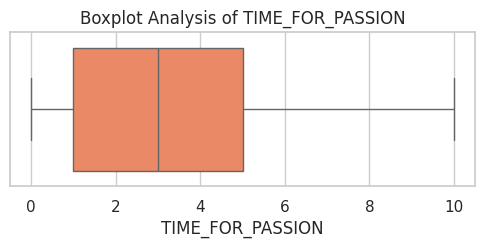

In [34]:
# CELL 4: DATA VISUALIZATION - DISTRIBUTIONS & INTERACTIONS
# 1. Feature Distribution Histograms
print("Generating feature distribution graphs...")
data.hist(figsize=(12, 8), bins=20, color="teal", edgecolor="black")
plt.suptitle("Statistical Distributions of Features and Target", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# 2. Pearson Correlation Heatmap
print("Generating correlation matrix heatmap...")
plt.figure(figsize=(10, 6))
corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Pearson Correlation Heatmap Matrix", fontsize=14)
plt.show()

# 3. Target Feature Interaction Bivariate Scatter plots
print("Generating target relationship scatter plots...")
for col in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=data, x=col, y=target, alpha=0.5, color="darkblue")
    plt.title(f"{col} vs Work Life Balance Score")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

# 4. Outlier Detection Boxplots
print("Generating diagnostic outlier boxplots...")
for col in features:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=data[col], color="coral")
    plt.title(f"Boxplot Analysis of {col}")
    plt.xlabel(col)
    plt.show()

In [35]:
# CELL 5: TRAIN-TEST PARTITIONING & FEATURE STANDARDIZATION
X = data[features]
y = data[target]

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and apply standard scaler to isolate scaled feature metrics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✔ Training set matrix dimension: {X_train_scaled.shape}")
print(f"✔ Testing set matrix dimension:  {X_test_scaled.shape}")

✔ Training set matrix dimension: (12776, 5)
✔ Testing set matrix dimension:  (3195, 5)


In [36]:
# CELL 6: MULTI-LAYER PERCEPTRON (NEURAL NETWORK) REGRESSOR
print("=== INITIATING NEURAL NETWORK DEPLOYMENT ===")

# Instantiating the Multi-Layer Perceptron Regressor
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

nn.fit(X_train_scaled, y_train)
pred_nn = nn.predict(X_test_scaled)

# Collect baseline Neural Network evaluation metrics
mae_nn = mean_absolute_error(y_test, pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, pred_nn))
r2_nn = r2_score(y_test, pred_nn)

print("\n--- Neural Network Testing Metrics Summary ---")
print(f"Mean Absolute Error (MAE):     {mae_nn:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_nn:.4f}")
print(f"R-squared Score (R²):           {r2_nn:.4f}")

=== INITIATING NEURAL NETWORK DEPLOYMENT ===

--- Neural Network Testing Metrics Summary ---
Mean Absolute Error (MAE):     25.2970
Root Mean Squared Error (RMSE): 31.2723
R-squared Score (R²):           0.4923


In [37]:
# CELL 7: CLASSICAL MODEL IMPLEMENTATION (LR & RF BASELINES)
print("=== DEPLOYING CLASSICAL MODEL ESTIMATOR BASELINES ===")

# Model A Baseline: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("\n--- Linear Regression Performance ---")
print(f"MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}")

# Model B Baseline: Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("\n--- Random Forest Baseline Performance ---")
print(f"MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f}")

=== DEPLOYING CLASSICAL MODEL ESTIMATOR BASELINES ===

--- Linear Regression Performance ---
MAE: 25.5856 | RMSE: 31.4984 | R²: 0.4850

--- Random Forest Baseline Performance ---
MAE: 27.1573 | RMSE: 33.8788 | R²: 0.4042


In [38]:
# CELL 8: HYPERPARAMETER SEARCH FOR MODEL OPTIMIZATION
print("=== RUNNING MULTI-CORE 5-FOLD CROSS-VALIDATION GRID SEARCH ===")

# Defined structural evaluation grid space
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("\n--- Hyperparameter Refinement Tuning Complete ---")
print(f"Optimal Hyperparameter Grid Config: {grid.best_params_}")
print(f"Best Validated Cross-Validation R²:  {grid.best_score_:.4f}")

=== RUNNING MULTI-CORE 5-FOLD CROSS-VALIDATION GRID SEARCH ===

--- Hyperparameter Refinement Tuning Complete ---
Optimal Hyperparameter Grid Config: {'max_depth': 10, 'n_estimators': 200}
Best Validated Cross-Validation R²:  0.5133


In [39]:
# CELL 9: WRAPPER-BASED RECURSIVE FEATURE ELIMINATION (RFE)
print("=== EXECUTING RECURSIVE FEATURE SELECTION ===")

# Restrict models down to the top 3 highest-contributing structural variables
target_selected_count = 3
selector = RFE(estimator=LinearRegression(), n_features_to_select=target_selected_count)
selector.fit(X_train_scaled, y_train)

# Isolate feature designations from indices array
selected_features = np.array(features)[selector.support_]
print(f"\n✔ Top {target_selected_count} Selected Features: {selected_features.tolist()}")

=== EXECUTING RECURSIVE FEATURE SELECTION ===

✔ Top 3 Selected Features: ['DAILY_STRESS', 'DAILY_STEPS', 'TIME_FOR_PASSION']


=== EXECUTING FINAL OPTIMIZED SYSTEM MODEL WITH REFINED FEATURES ===

             TABLE 5: PERFORMANCE COMPARISON SUMMARY CHART (REGRESSION)
           Model Stage / Variant Features Used   MAE  RMSE R² Score
            Neural Network (MLP)       All (5) 25.30 31.27     0.49
       Model A Baseline (Linear)       All (5) 25.59 31.50     0.48
Model B Baseline (Random Forest)       All (5) 27.16 33.88     0.40
Final Model (Optimized RF + RFE)  Selected (3) 26.63 33.04     0.43


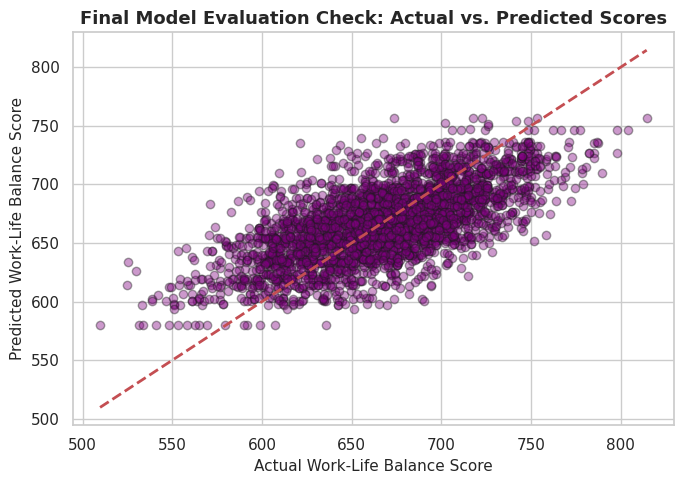

In [40]:
# CELL 10: FINAL PIPELINE EXECUTION & STRUCTURAL EVALUATION SUMMARY
print("=== EXECUTING FINAL OPTIMIZED SYSTEM MODEL WITH REFINED FEATURES ===")

# Re-slice feature spaces down strictly to the features selected by RFE
X_subset = data[selected_features]
y_subset = data[target]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

# Standardize final optimized data subsets
scaler_f = StandardScaler()
X_train_f_scaled = scaler_f.fit_transform(X_train_f)
X_test_f_scaled = scaler_f.transform(X_test_f)

# Train the finalized model combining the optimal grid hyperparameters and selected features
final_model = RandomForestRegressor(**grid.best_params_, random_state=42)
final_model.fit(X_train_f_scaled, y_train_f)
pred_final = final_model.predict(X_test_f_scaled)

# Final performance calculations
rmse_final = np.sqrt(mean_squared_error(y_test_f, pred_final))
r2_final = r2_score(y_test_f, pred_final)
mae_final = mean_absolute_error(y_test_f, pred_final)

# Fixed: Explicitly using square brackets [] to avoid set generation errors
regression_summary_data = [
    ["Model Stage / Variant", "Features Used", "MAE", "RMSE", "R² Score"],
    ["Neural Network (MLP)", f"All ({len(features)})", f"{mae_nn:.2f}", f"{rmse_nn:.2f}", f"{r2_nn:.2f}"],
    ["Model A Baseline (Linear)", f"All ({len(features)})", f"{mae_lr:.2f}", f"{rmse_lr:.2f}", f"{r2_lr:.2f}"],
    ["Model B Baseline (Random Forest)", f"All ({len(features)})", f"{mae_rf:.2f}", f"{rmse_rf:.2f}", f"{r2_rf:.2f}"],
    ["Final Model (Optimized RF + RFE)", f"Selected ({len(selected_features)})", f"{mae_final:.2f}", f"{rmse_final:.2f}", f"{r2_final:.2f}"]
]

summary_df = pd.DataFrame(regression_summary_data[1:], columns=regression_summary_data[0])

print("\n" + "="*90)
print("             TABLE 5: PERFORMANCE COMPARISON SUMMARY CHART (REGRESSION)")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)

# Final Evaluation Figure Generation: Actual vs Predicted Values
plt.figure(figsize=(7, 5))
plt.scatter(y_test_f, pred_final, alpha=0.4, color="purple", edgecolor="k")
# Add perfect fit identity projection diagonal line
plt.plot([y_test_f.min(), y_test_f.max()], [y_test_f.min(), y_test_f.max()], 'r--', lw=2)
plt.xlabel("Actual Work-Life Balance Score", fontsize=11)
plt.ylabel("Predicted Work-Life Balance Score", fontsize=11)
plt.title("Final Model Evaluation Check: Actual vs. Predicted Scores", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("regression_final_actual_vs_predicted.png", dpi=300)
plt.show()